# Swiggy Sales Analysis

### Import Libraries

In [1]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

from warnings import filterwarnings

### Importing data

In [3]:
df = pd.read_excel('swiggy_data.xlsx')

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [5]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### metadata

In [6]:
print("NO of Rows: ",df.shape[0])

NO of Rows:  197430


In [7]:
print("No of Fileds: ",df.shape[1])

No of Fileds:  10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [9]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [10]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# KPI's

### Total Sales

In [11]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [12]:
total_sales= df["Price (INR)"].sum()

print("Total Sales: ",round(total_sales,2))



Total Sales:  53012505.77


### Average Rating

In [13]:
av_rating= df["Rating"].mean()

print("Average Rating: ",round(av_rating,1))

Average Rating:  4.3


### Average Order Value

In [14]:
avg_order_value = df["Price (INR)"].mean()

print("Avg Order Value: ",round(avg_order_value,2))

Avg Order Value:  268.51


### Ratings Count

In [15]:
rating_count= df["Rating Count"].sum()

print("Total Rating Count: ",rating_count)

Total Rating Count:  5591574


### Total orders

In [16]:
print("Total Orders: ",len(df))

Total Orders:  197430


## Charts Design

### Monthly Sales Trend

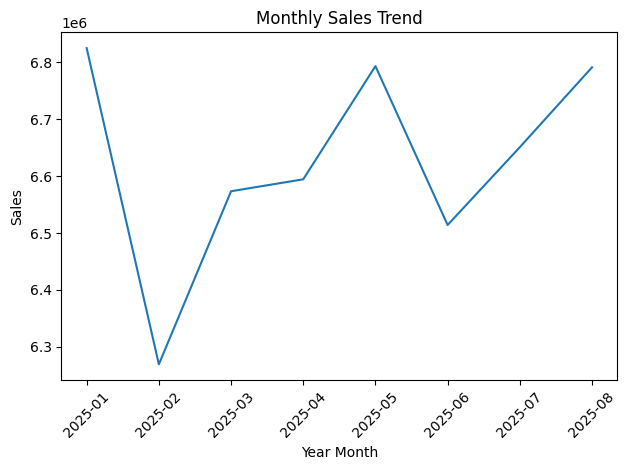

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("Year Month")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["Year Month"],monthly_revenue["Price (INR)"])
plt.xlabel("Year Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Daily Sales Trend

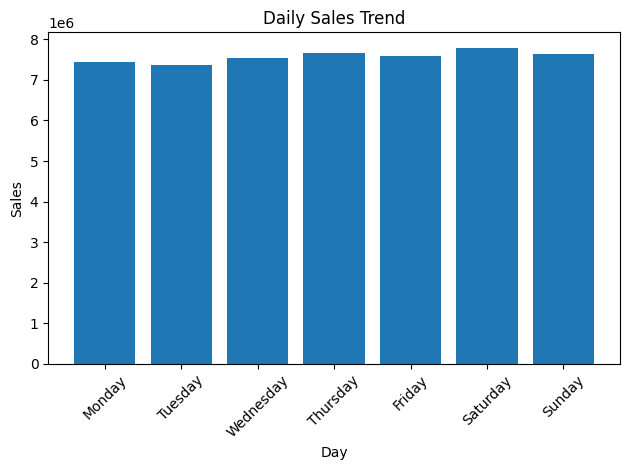

In [18]:
df["Dry Name"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("Dry Name")["Price (INR)"]
    .sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    
)

plt.figure()
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Sales Trend")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Total Sale by Food Type (Veg vs Non-veg)

In [19]:
non_veg_keywords = [
    "chicken",
    "mutton",
    "fish",
    "prawn",
    "crab",
    "lobster",
    "kebab",
    "kabab",
    "non-veg",
    "non veg",
    
]


df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na = False),
    "Non-Veg",
    "Veg"
)

In [20]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

In [21]:
pip install --upgrade nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
fig = px.pie(food_revenue,
             values = "Price (INR)",
             names = "Food Category",
             hole = 0.5,
             title = "Revenue contribution : Veg vs Non-Veg"
)

fig.update_traces(textposition = "inside",
                  textinfo = "percent+label",
                  pull = [0.05,0]
)

fig.update_layout(
    height = 500,
    margin = dict(l = 100,r = 100,t = 100,b = 100)
)

fig.show()

### Total Sales by State

In [ ]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values(by = "Price (INR)", ascending = False),
    x = "Price (INR)",
    y = "State",
    title = "Total Sales by State",
    color = "State",
    color_continuous_scale = "Viridis"
)